# TP Integrador Interpolación



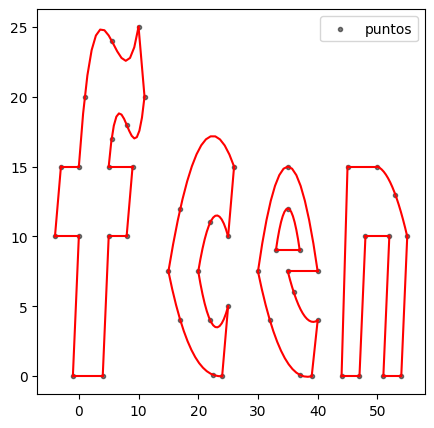

In [ ]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lectura de datos
puntos = pd.read_csv("TPs/puntos.csv", sep=",", names = ["X", "Y"])
curvas = pd.read_csv("TPs/curvas.csv", sep=",", names = ["P1", "P2", "P3", "P4"])
puntos.index = puntos.index + 1

# Procesamiento de curvas 

# Esta funcion accede a las curvas[i] y retorna 
def asociar_curva_puntos(curva, puntos = puntos)->tuple[list]:
    px = []
    py = []
    for p in curva:
        if p == 0:
            continue
        px.append(puntos.loc[p]["X"])
        py.append(puntos.loc[p]["Y"])
    # Regresa una tupla con dos listas conteniendo las coordenadas x e y asociadas a una curva.
    return (px, py)

# Interpola los puntos y retorna la curva interpolante con su dominio.
def interpolar_puntos(pxpy:tuple[list]) -> tuple:
    cant_puntos = len(pxpy[0])
    coef = np.polyfit(pxpy[0], pxpy[1], cant_puntos-1)  # Interpolación
    curva = np.poly1d(coef)
    dominio = (min(pxpy[0]), max(pxpy[0]))
    return (curva, dominio)

# Toma la informacion de la curva y devuelve un plot
def graficar_curva(info_curva:tuple)->list[plt.Line2D]:
    curva = info_curva[0]
    dominio = info_curva[1]
    X = np.linspace(start=dominio[0], stop=dominio[1], num=15) # Genera 15 particiones del dominio
    Y = np.polyval(curva, X) # Evalua 
    return plt.plot(X, Y, color="red")

# Funcion main, recorre el dataframe curvas, curva por curva y genera el plot. 
def main():
    plt.figure(figsize=(5,5))
    for i in range(len(curvas)):
        curva = curvas.loc[i].values
        a = asociar_curva_puntos(curva)
        info_curva = interpolar_puntos(a)
        graficar_curva(info_curva)
    plt.scatter(puntos["X"], puntos["Y"], color = "black", marker=".", alpha=0.5, label="puntos")
    plt.legend()
    plt.show()
        
main()
